In [1]:
# Setup environment
import sys
import os.path
%pip install atlasopenmagic
from atlasopenmagic import install_from_environment
install_from_environment()

Defaulting to user installation because normal site-packages is not writeable
Note: you may need to restart the kernel to use updated packages.
Installing packages: ['aiohttp>=3.9.5', 'atlasopenmagic>=1.2.0', 'awkward>=2.6.7', 'awkward-pandas>=2023.8.0', 'coffea~=0.7.0', 'fsspec>=2025.7.0', 'hist>=2.8.0', 'ipykernel>=6.29.5', 'jupyter>=1.0.0', 'lmfit>=1.3.2', 'matplotlib>=3.9.1', 'metakernel>=0.30.2', 'notebook<7', 'numpy>=1.26.4', 'pandas>=2.2.2', 'papermill>=2.6.0', 'pip>=24.2', 'scikit-learn>=1.5.1', 'uproot>=5.3.10', 'uproot3>=3.14.4', 'fsspec-xrootd>=0.5.1', 'jupyterlab_latex~=3.1.0', 'vector>=1.4.1']
  Using cached coffea-0.7.31-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached ipykernel-6.31.0-py3-none-any.whl.metadata (4.5 kB)
INFO: pip is looking at multiple versions of coffea to determine which version is compatible with other requirements. This could take a while.
  Using cached coffea-0.7.30-py2.py3-none-any.whl.metadata (9.6 kB)
  Using cached coffea-0.7.29-py2.py3-non

In [2]:
# Import basic libraries
import copy
import os

# In case any of these imports fails, please restart the jupyter kernel and try again - it is likely the environment just needs to be updated
import requests
import uproot   # handle ROOT files
import awkward as ak    # nested, variable sized data arrays
import numpy as np
import vector   # Lorentz vectors
vector.register_awkward()
import matplotlib.pyplot as plt # plotting
import matplotlib
plt.rcParams.update({
    "font.family": "sans-serif",
    "font.sans-serif": ["Helvetica","Arial","Nimbus Sans","DejaVu Sans"],
    "svg.fonttype": "path"
})
from tqdm import tqdm   # progress bars
import atlasopenmagic as atom   # ATLAS Open Data
from concurrent.futures import ProcessPoolExecutor, as_completed # Parallel execution for processing large datasets
import time

In [3]:
# - Useful plotting functions - #
# Use innerward facing ticks in all direction
def inner_ticks(ax:matplotlib.axes.Axes):
    ax.tick_params(direction="in",which="both",top=True,right=True)

# Plot an ATLAS Open Data label on a pair of axes
def atlas_label(ax:matplotlib.axes.Axes,loc="upper right",text="Open Data",fontsize=16,pos_ovr=None):
    locs = {
        "upper left" : (.04, .88),
        "upper right": (.96, .88),
    }
    if (pos_ovr is not None) and isinstance(pos_ovr,tuple):
        pos = pos_ovr 
    else: pos = locs[loc]
    align = ("left","right","center"); ha = "left"
    for a in align:
        if a in loc: ha = a
    ax.text(
        *pos,r"$\mathbfit{ATLAS}$ "+text,
        transform=ax.transAxes,fontsize=fontsize,ha=ha,va="bottom"
    )

In [28]:
atom.set_release("2024r-hi")
sample_defs = {
    "Data": {'dids': ["data"], 'color': 'red'}
}
data_samples = atom.build_dataset(sample_defs,skim="noskim",protocol="https",cache=False)
samples = {**data_samples}

Fetching and caching all metadata for release: 2024r-hi...
Successfully cached 2 datasets.
Active release: 2024r-hi. (Datasets path: REMOTE)


In [29]:
bins, h_range = 100, (0,5e6)
fine_bins = int(5e6 / 10e3) # Bins for 2 GeV bin width
print(fine_bins) 
_ , bin_edges = np.histogram([-1],fine_bins,h_range)

500


In [30]:
urls = atom.get_urls("data",protocol="https",cache=False)
# Switch to atom build dataset
fraction = 0.01
variables = [f"EventInfoAuxDyn.FCalEt{x}" for x in ("A","C")]
def process_dataset(url:str,loop:int):
    if loop > 99: raise IndexError("Can't iterate past 100 pct of the dataset!")
    with uproot.open(f"{url}:CollectionTree") as tree:

        total_hist,_ = np.histogram([-1],bins=fine_bins,range=h_range)
        for data in tree.iterate(variables, library="ak", entry_start=int(tree.num_entries*loop*fraction), entry_stop=int(tree.num_entries*(loop+1)*fraction)):
            total_et = data[variables[0]] + data[variables[1]]
            this_hist,_ = np.histogram(total_et,bins=fine_bins,range=h_range)
            total_hist = total_hist + this_hist
            
    return total_hist
            
blocks = " ▁▂▃▄▅▆▇█"

def to_sparkline(hist):
    if max(hist) == 0:
        return blocks[0] * len(hist)
    normalised = hist / max(hist)
    return f'{"".join(blocks[int(v * (len(blocks) - 1))] for v in normalised)} Events: {int(np.sum(hist))}'

total_hist = process_dataset(urls[0],99)
print(to_sparkline(total_hist))

          ▂  ▂ ▄█▂ ▂▂▂  ▂▂   ▄▂▂ ▂       ▂  ▂ ▂ ▂▂ ▄ ▂   ▂       ▂     ▂ ▂ ▂▂     ▂     ▂  ▄ ▂   ▂    ▂        ▄     ▂      ▂               ▂ ▂                            ▂         ▂     ▂▂    ▂                       ▂    ▂ ▂              ▄   ▂  ▂                   ▂▂      ▂  ▂  ▂       ▂        ▂                  ▂▂                                              ▂ ▂      ▂    ▂                     ▂      ▂      ▂      ▂       ▂ ▄                                                                     Events: 78


In [31]:
def parallel_processing(url:str):
    with ProcessPoolExecutor(max_workers=4) as executor:
        futures = {
            executor.submit(process_dataset, url, i): i for i in range(100)
        }

        results = []
        for future in as_completed(futures):
            try: results.append(future.result())
            except Exception as e:
                print(f"Error in {futures[future]}! Got {e}")

        result_hist = np.sum(results,axis=0)

        return result_hist      

In [32]:
print(samples["Data"]["list"][:2])

['https://opendata.cern.ch/eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691901._000001.pool.root.1', 'https://opendata.cern.ch/eos/opendata/atlas/rucio/data15_hi/DAOD_HION14.41691901._000002.pool.root.1']


In [33]:
start_all = time.time()
hists_all = {}
# Get bin edges and empty histogram
total_eT_hist, bin_edges = np.histogram([-1],bins=fine_bins,range=h_range)
print("Processing datasets...")
pbar = tqdm(samples["Data"]["list"][:10],desc=to_sparkline(np.array([total_eT_hist[int((len(total_eT_hist)-1)/50)*i] for i in range(50)])))
for url in pbar:
    frames = []
    H = parallel_processing(url)
    frames.append(H)
    total_eT_hist = total_eT_hist + np.sum(frames,axis=0)
    pbar.set_description(to_sparkline(np.array([total_eT_hist[int((len(total_eT_hist)-1)/50)*i] for i in range(50)])))
    # bar = " ".join([f"{v:.2f}" for v in total_eT_hist])
    # sys.stdout.write(f"{i+1}/{len(urls)}: \r{bar}")
    # sys.stdout.flush()

end_all = time.time()
print(f"Total time: {round((end_all - start_all) / 60, 1)} mins")

Processing datasets...


                                                  :   0%|          | 0/10 [00:00<?, ?it/s]

Error in 50! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 51! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 53! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 52! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 54! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 55! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 48! Got 'ClientResponseError' object is not subscriptable
Error in 56! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 57! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 58! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 59! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 60! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 61! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 63! Got can'

 ▁█▄▃▄▂▂▂▂▁▂▁▁▁▁ ▁▁ ▂ ▁▁   ▁     ▁ ▁ ▁   ▁         Events: 433:  10%|█         | 1/10 [00:06<01:02,  6.90s/it]

Error in 7! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 8! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 9! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 10! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 11! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 12! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 13! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 14! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 15! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 16! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 17! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 18! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 19! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 20! Go

...

Error in 99! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 0! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 2! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 4! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 5! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 6! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 3! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 1! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 7! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 8! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 11! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 12! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 13! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 14! Got can'

 ▁█▄▄▃▂▃▂▂▁▂▁▂▁▁▁▁▁ ▁▁▁▁   ▁▁ ▁  ▁ ▁ ▁   ▁         Events: 966:  90%|█████████ | 9/10 [00:25<00:01,  1.68s/it]

Error in 94! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 95! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 96! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 97! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 99! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 98! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 2! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 4! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 0! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 1! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 3! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 5! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 9! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 10! Got ca

 ▁█▄▄▃▂▃▂▂▁▂▁▂▁▁▁▁▁ ▁▁▁▁   ▁▁ ▁  ▁ ▁ ▁   ▁         Events: 966: 100%|██████████| 10/10 [00:26<00:00,  2.61s/it]

Error in 97! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 99! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Error in 98! Got can't pickle multidict._multidict.CIMultiDictProxy objects
Total time: 0.4 mins


In [34]:
print(total_eT_hist)

[  0.   1.   0.   0.   0.   0.   0.   0.   1.  13.  59. 115. 121. 106.
 101.  94.  88.  78. 101.  98.  82.  82.  72.  62.  73.  86.  76.  63.
  64.  70.  77.  51.  62.  55.  57.  69.  60.  45.  50.  49.  42.  52.
  46.  45.  42.  46.  48.  49.  43.  39.  55.  44.  43.  39.  31.  37.
  32.  41.  40.  34.  39.  34.  32.  43.  32.  34.  41.  38.  41.  23.
  37.  32.  33.  35.  32.  36.  35.  33.  33.  31.  36.  34.  35.  40.
  27.  29.  36.  27.  26.  30.  24.  28.  24.  29.  34.  39.  34.  36.
  24.  31.  12.  22.  22.  25.  30.  22.  23.  26.  23.  24.  33.  20.
  23.  27.  28.  23.  26.  26.  18.  21.  26.  18.  26.  18.  20.  18.
  19.  23.  18.  11.  16.  20.  30.  20.  18.  21.  18.  23.  18.  26.
  24.  14.  15.  27.  17.  10.  22.  19.  20.  12.  16.  18.  15.  22.
  25.  18.  20.  18.  16.  17.  18.  10.  18.  20.  16.  11.  15.  15.
  18.  16.  18.  11.  12.  14.  22.  14.  18.  12.  18.  19.  21.  14.
  15.  19.  20.  18.  13.  13.  17.  15.  14.  11.  18.  19.  19.  16.
  19. 

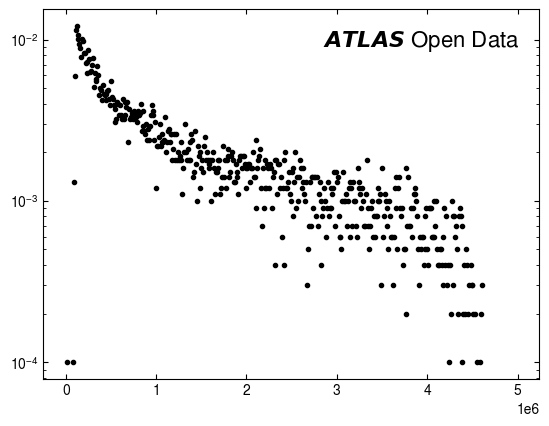

In [35]:
fig, ax = plt.subplots()
nbins = 50

diff_hist = total_eT_hist / (bin_edges[1] - bin_edges[0])
# ax.stairs(diff_hist,bin_edges*1e-6,color="blue")
ax.scatter(bin_edges[:-1],diff_hist,color="black",marker=".")
ax.set_yscale("log")
inner_ticks(ax); atlas_label(ax)

In [ ]:
total_transverse_energies = ak.Array([])

for i,url in tqdm(enumerate(urls),desc="Grabbing total transverse energies...",total=len(urls)):
    with uproot.open(f"{url}:CollectionTree") as tree:
        fcal = ak.zip({
        branch.split(".")[1]: tree[branch].array() for branch in (
            f"EventInfoAuxDyn.FCalEt{x}" for x in ("A","C")
        )})
        fcal["TotalEt"] = fcal["FCalEtA"] + fcal["FCalEtC"]
        total_transverse_energies = ak.concatenate([total_transverse_energies,ak.flatten(fcal["TotalEt"],axis=None)])
    if i == 2: break

print(total_transverse_energies)

Grabbing total transverse energies...:   0%|          | 0/1913 [00:00<?, ?it/s]


TypeError: 'ClientResponseError' object is not subscriptable

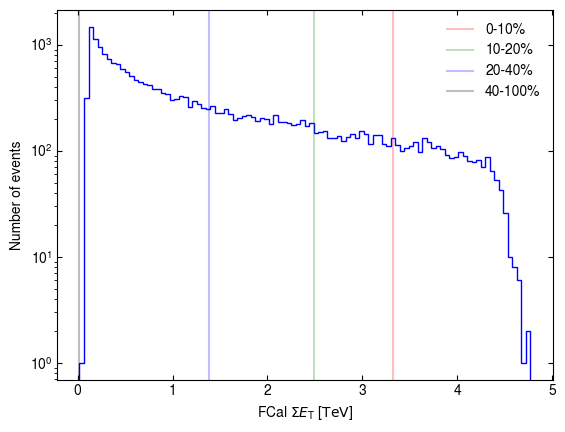

In [ ]:
fig, ax = plt.subplots()
ax.hist(total_transverse_energies*1e-6,bins=100,histtype="step",color="blue")
ax.tick_params(axis="both",direction="in",top=True,right=True)
ax.set_yscale("log")
ax.set_xlabel(r"FCal $\Sigma E_\mathrm{T}$ [$\mathrm{TeV}$]")
ax.set_ylabel("Number of events")
centrality_ranges = {
    10: "0 - 10%",
    20: "10 - 20%",
    40: "20 - 40%",
    100:"40 - 100%"
}
centralities = [0,10,20,40,100]
centrality_bins = np.array([np.percentile(total_transverse_energies,100-x) for x in centralities[1:]])
ymax = ax.get_ylim()[1]
# plt.vlines(centrality_bins*1e-6,0,ymax,alpha=.33,color="k")
for i,colour in zip(range(4),("red","green","blue","k")):
    plt.vlines(centrality_bins[i]*1e-6,0,ymax,color=colour,alpha=.25,label=f"{centralities[i]}-{centralities[i+1]}%")

plt.legend(frameon=False)

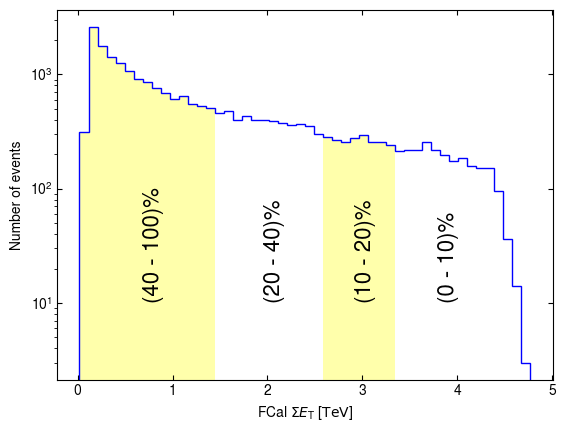

In [ ]:
fig, ax = plt.subplots()
nbins = 50
entries, bin_edges = np.histogram(total_transverse_energies*1e-6, bins=nbins)

centrality_ranges = {
    10: "(0 - 10)%",
    20: "(10 - 20)%",
    40: "(20 - 40)%",
    100:"(40 - 100)%"
}
centralities = [0,10,20,40,100]
centrality_bins = np.array([bin_edges[-1]])
centrality_bins = np.concatenate([centrality_bins,np.array([np.percentile(total_transverse_energies,100-x) for x in centralities[1:]])*1e-6],)

colours = ["white","yellow","white","yellow"]
for i in range(len(centrality_bins)-1):
    mask = (bin_edges[:-1] <= centrality_bins[i]) & (bin_edges[:-1] >= centrality_bins[i+1])
    masked_entries = np.where(mask,entries,0)
    y_txt = 10
    x_txt = np.median(bin_edges[mask]) if i != 0 else 3.8
    ax.stairs(masked_entries,bin_edges,fill=True,color=colours[i],alpha=.33,label="hi")
    ax.text(x_txt,y_txt,centrality_ranges[centralities[i+1]],rotation=90,fontsize=16,ha="left",va="bottom")

ax.tick_params(axis="both",direction="in",top=True,right=True)
ax.set_yscale("log")
ax.set_xlabel(r"FCal $\Sigma E_\mathrm{T}$ [$\mathrm{TeV}$]")
ax.set_ylabel("Number of events")
_ = ax.stairs(entries, bin_edges, color="blue")